# Anomaly Classifier Notebook

This notebook validates the classification component of **AeroNet Pro / AeroNet Lite**. The goal is to classify drone telemetry into normal and anomalous states using interpretable ML models.

In [1]:
from pathlib import Path
import os
import sys

# This notebook is intended to be placed inside the notebooks/ folder.
# It automatically switches to the project root so imports and relative paths work.
cwd = Path.cwd()
if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
elif (cwd / "app.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "app.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

for folder in ["outputs", "report/figures", "data/processed"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\acer\Downloads\aeronet_pro\aeronet_pro


## 1. Import libraries and project ML functions

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from ml_models import load_drone_log, prepare_anomaly_labels, train_anomaly_model

## 2. Load drone telemetry / operations data

The project function first looks for `data/raw/drone_operations_log.csv`. If that file is not available, it creates reproducible synthetic telemetry data so the notebook remains runnable during viva/demo.

In [3]:
raw_df = load_drone_log()
print(f"Raw telemetry shape: {raw_df.shape}")
raw_df.head()

Raw telemetry shape: (552, 22)


,Drone ID,Application,Drone Size,Drone Model,Manufacturer,Propeller Count,Max Carry Weight (kg),Actual Carry Weight (kg),Payload Type,Payload Description,...,Distance Flown (km),Operator ID,Flight Date,Battery Remaining (%),GPS Accuracy (meters),Wind Speed (m/s),Obstacles Encountered,Flight Status,Regulatory Approval ID,Notes
0,D001,Package Delivery,Medium,FlyHigh 300,AeroCorp,4,5.0,2.5,Package,Small consumer goods,...,8.0,OP001,2025-03-20,85,2.1,3.5,No,Completed,REG-2025-ABC-123,"Urban delivery, light package, good weather"
1,D002,Infrastructure Inspection,Large,Inspecta X,SkyView Inc.,6,15.0,8.0,"Camera, Sensor","High-resolution camera, thermal sensor",...,15.0,OP002,2025-03-21,68,1.8,6.2,Yes,Completed,REG-2025-DEF-456,"Bridge inspection, carried specialized equipment"
2,D003,Agricultural Spraying,Large,CropMaster,AgriDrones,8,20.0,18.0,Liquid Tank,Pesticide solution,...,10.0,OP003,2025-03-22,40,3.5,7.8,Yes,Completed,REG-2025-GHI-789,"Field spraying, full tank, moderate wind"
3,D004,Aerial Photography,Small,SnapShot Mini,PhotoFly,4,1.0,0.5,Camera,Lightweight action camera,...,5.0,OP004,2025-03-23,92,1.2,2.1,No,Completed,REG-2025-JKL-012,"Recreational use, clear skies"
4,D005,Surveillance,Medium,Watcher Pro,SecureTech,4,7.0,3.0,"Camera, Sensor","Infrared camera, motion detection sensor",...,12.0,OP005,2025-03-24,55,2.5,4.9,No,Completed,REG-2025-MNO-345,"Security patrol, nighttime operation"


## 3. Prepare anomaly labels

Labels are generated using rule-based telemetry logic. Examples include low battery, poor GPS accuracy, obstacle encounter, high wind speed, abnormal altitude, or failed/warning flight status.

In [4]:
labeled_df = prepare_anomaly_labels(raw_df)
label_counts = labeled_df["label"].value_counts().reset_index()
label_counts.columns = ["label", "count"]
label_counts

,label,count
0,route_anomaly,240
1,sensor_weather_anomaly,200
2,normal,112


## 4. Train anomaly classifiers

The notebook compares Decision Tree and Random Forest classifiers. The best model is selected based on accuracy.

In [5]:
anomaly_result = train_anomaly_model()

summary = pd.DataFrame([{
    "Best Model": anomaly_result["best_name"],
    "Accuracy": anomaly_result["accuracy"]
}])

summary

,Best Model,Accuracy
0,Decision Tree,0.986


In [6]:
anomaly_result["results"]

,Model,Accuracy
0,Decision Tree,0.986
1,Random Forest,0.986


## 5. Classification report

In [7]:
print(anomaly_result["report"])

                        precision    recall  f1-score   support

                normal       1.00      1.00      1.00        28
         route_anomaly       0.98      0.98      0.98        60
sensor_weather_anomaly       0.98      0.98      0.98        50

              accuracy                           0.99       138
             macro avg       0.99      0.99      0.99       138
          weighted avg       0.99      0.99      0.99       138



## 6. Confusion matrix

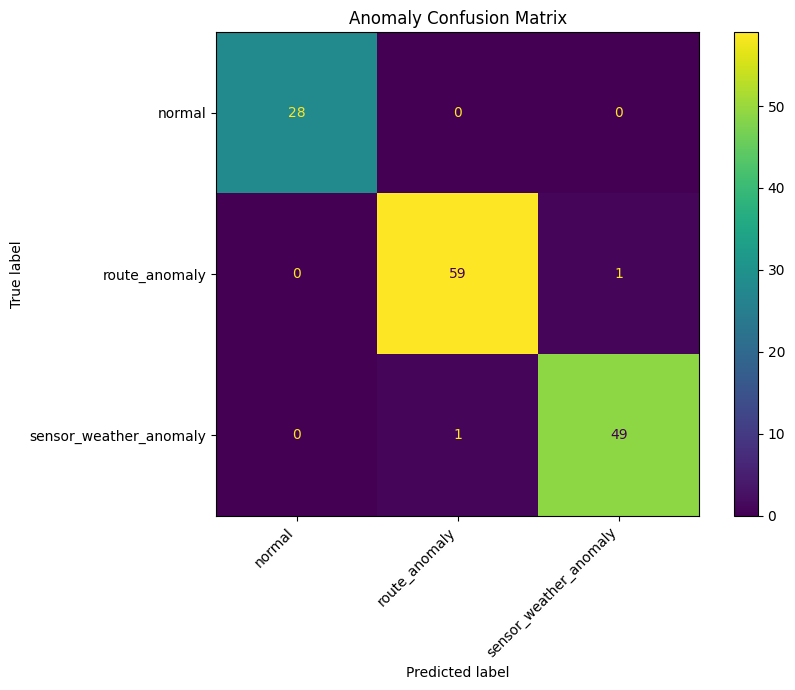

In [8]:
labels = anomaly_result["labels"]
cm = anomaly_result["cm"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, values_format="d")
ax.set_title("Anomaly Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("report/figures/notebook_anomaly_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Save notebook outputs

These files are saved for the `outputs/` and `data/processed/` folders.

In [9]:
anomaly_result["results"].to_csv("outputs/anomaly_classification_metrics.csv", index=False)

pd.DataFrame(
    anomaly_result["cm"],
    index=anomaly_result["labels"],
    columns=anomaly_result["labels"]
).to_csv("outputs/anomaly_confusion_matrix.csv")

with open("outputs/anomaly_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(anomaly_result["report"])

anomaly_result["df"].to_csv("data/processed/labeled_anomaly_data.csv", index=False)

print("Saved:")
print("- outputs/anomaly_classification_metrics.csv")
print("- outputs/anomaly_confusion_matrix.csv")
print("- outputs/anomaly_classification_report.txt")
print("- data/processed/labeled_anomaly_data.csv")
print("- report/figures/notebook_anomaly_confusion_matrix.png")

Saved:
- outputs/anomaly_classification_metrics.csv
- outputs/anomaly_confusion_matrix.csv
- outputs/anomaly_classification_report.txt
- data/processed/labeled_anomaly_data.csv
- report/figures/notebook_anomaly_confusion_matrix.png


## 8. Short conclusion

The anomaly detection component classifies drone telemetry into operational states such as normal, route anomaly, battery anomaly, or sensor/weather anomaly. This supports the simulation's safety layer because detected anomalies can trigger rerouting or return-to-hub actions.